In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

db = pd.read_csv('database/nanopore_trace_database.csv')

In [10]:
IOS = 240

In [11]:
def plot_trace(database: pd.DataFrame, trace_id: int = 0):
    """
    Plot a single trace from the database, coloured by region.
    Use this as a sanity check after generating the database.
    """
    trace = database[database['trace_id'] == trace_id]
    peptide = trace['peptide_sequence'].iloc[0]

    colors = {
        'DNA':        'steelblue',
        'linker':     'green',
        'peptide':    'orange'
    }

    fig, ax = plt.subplots(figsize=(13, 5))
    for region, group in trace.groupby('region', sort=False):
        ax.plot(group['time_ms'], group['current_pA'],
                label=region, color=colors[region], linewidth=0.8)

    ax.axhline(IOS, color='gray', linestyle='--', alpha=0.4, label='IOS reference')
    ax.set_title(f'Trace {trace_id} — Peptide: {peptide}')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Current (pA)')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

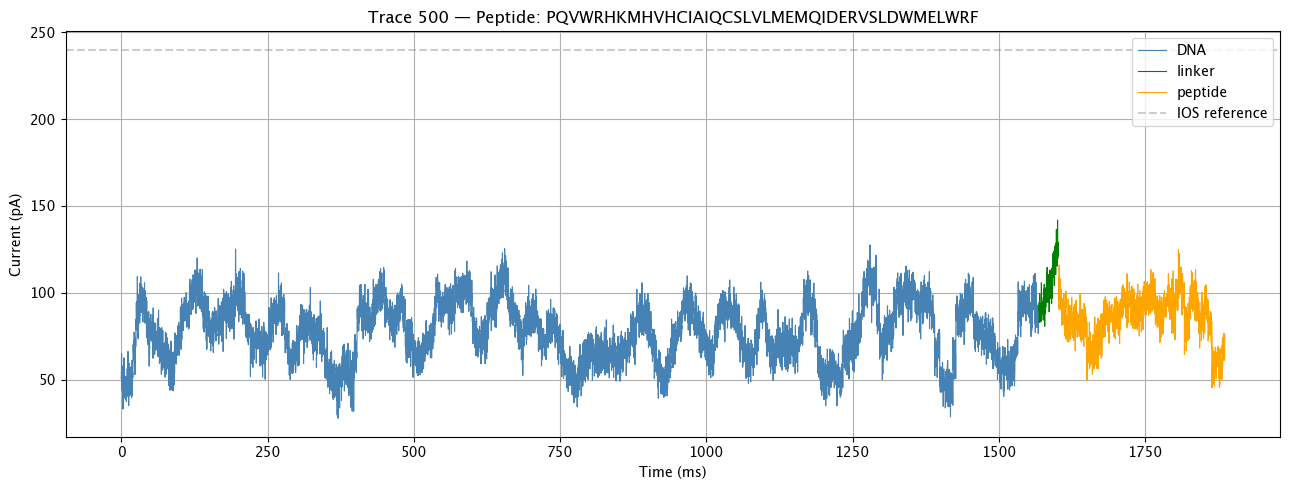

In [13]:

trace_id = 500

plot_trace(db, trace_id)
